In [ ]:
!pip install pandas-datareader

In [ ]:
pip install git+https://github.com/pydata/pandas-datareader.git

In [ ]:
!pip install tensorflow

In [5]:
import pandas_datareader as pdr
import os
import datetime

In [6]:
print(pdr.__version__)

0.11.0.dev76+g4ff6214


In [7]:
api_key = "15095e1f5aec5f9128b48eeeb302e275af9d7591"

In [ ]:
df = pdr.get_data_tiingo("AAPL", api_key = api_key)

In [5]:
df.to_csv("AAPL.csv")

In [11]:
df

,date,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,adjVolume,divCash,splitFactor
symbol,,,,,,,,,,,,,
AAPL,2020-09-11 00:00:00+00:00,112.000,115.2300,110.0000,114.570,180860325,108.955161,112.097350,107.009533,111.455293,180860325,0.0,1.0
AAPL,2020-09-14 00:00:00+00:00,115.355,115.9300,112.8000,114.720,140150087,112.218952,112.778320,109.733412,111.601215,140150087,0.0,1.0
AAPL,2020-09-15 00:00:00+00:00,115.540,118.8290,113.6100,118.330,184642039,112.398923,115.598508,110.521392,115.113073,184642039,0.0,1.0
AAPL,2020-09-16 00:00:00+00:00,112.130,116.0000,112.0400,115.230,155026675,109.081627,112.846417,108.994074,112.097350,155026675,0.0,1.0
AAPL,2020-09-17 00:00:00+00:00,110.340,112.2000,108.7100,109.720,178010968,107.340290,109.149724,105.754603,106.737145,178010968,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
AAPL,2025-09-03 00:00:00+00:00,238.470,238.8500,234.3600,237.210,66061716,238.470000,238.850000,234.360000,237.210000,66061716,0.0,1.0
AAPL,2025-09-04 00:00:00+00:00,239.780,239.8999,236.7400,238.450,47549429,239.780000,239.899900,236.740000,238.450000,47549429,0.0,1.0
AAPL,2025-09-05 00:00:00+00:00,239.690,241.3200,238.4901,239.995,54870397,239.690000,241.320000,238.490100,239.995000,54870397,0.0,1.0


In [12]:
df_close = df.reset_index()['close']

In [13]:
df_close

0       112.000
1       115.355
2       115.540
3       112.130
4       110.340
         ...   
1249    238.470
1250    239.780
1251    239.690
1252    237.880
1253    234.350
Name: close, Length: 1254, dtype: float64

In [14]:
df_close.shape

(1254,)

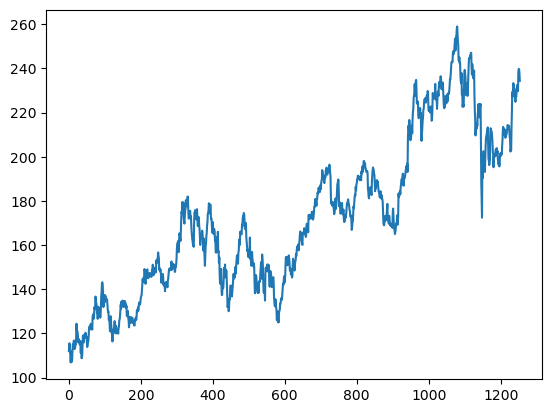

In [15]:
import matplotlib.pyplot as plt
plt.plot(df_close)

In [16]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

In [17]:
scaler = MinMaxScaler(feature_range=(0,1))
df_close = scaler.fit_transform(np.array(df_close).reshape(-1,1))

In [18]:
df_close

array([[0.03390722],
       [0.05595348],
       [0.05716914],
       ...,
       [0.87297937],
       [0.86108556],
       [0.83788934]])

In [19]:
df_close.shape

(1254, 1)

In [20]:
train_size = int(len(df_close) * 0.7)
test_size = len(df_close) - train_size
train_data, test_data = df_close[0:train_size, :], df_close[train_size:len(df_close), :1] 

In [142]:
import numpy

def create_dataset(dataset, time_step=1):
	dataX, dataY = [], []
	for i in range(len(dataset)-time_step-1):
		a = dataset[i:(i+time_step), 0]
		dataX.append(a)
		dataY.append(dataset[i + time_step, 0])
	return numpy.array(dataX), numpy.array(dataY)

In [143]:
time_step = 100
X_train, y_train = create_dataset(train_data, time_step)
X_test, y_test = create_dataset(test_data, time_step)

In [144]:
print(X_train.shape), print(y_train.shape)

(776, 100)
(776,)


(None, None)

In [145]:
print(X_test.shape), print(y_test.shape)

(276, 100)
(276,)


(None, None)

In [146]:
X_train = X_train.reshape(X_train.shape[0],X_train.shape[1] , 1)
X_test = X_test.reshape(X_test.shape[0],X_test.shape[1] , 1)

In [147]:
X_train.shape

(776, 100, 1)

In [148]:
X_test.shape

(276, 100, 1)

In [151]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM

In [152]:
model=Sequential()
model.add(LSTM(50,return_sequences=True,input_shape=(100,1)))
model.add(LSTM(50,return_sequences=True))
model.add(LSTM(50))
model.add(Dense(1))
model.compile(loss='mean_squared_error',optimizer='adam')

C:\Users\kagan\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [153]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_9 (LSTM)                   │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 100, 50)        │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,851 (198.64 KB)

 Trainable params: 50,851 (198.64 KB)

 Non-trainable params: 0 (0.00 B)

In [154]:
model.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=100,batch_size=64,verbose=1)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 255ms/step - loss: 0.0290 - val_loss: 0.0913
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 179ms/step - loss: 0.0067 - val_loss: 0.0171
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 181ms/step - loss: 0.0036 - val_loss: 0.0122
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 208ms/step - loss: 0.0030 - val_loss: 0.0104
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 193ms/step - loss: 0.0025 - val_loss: 0.0060
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 170ms/step - loss: 0.0023 - val_loss: 0.0048
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 151ms/step - loss: 0.0023 - val_loss: 0.0054
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 148ms/step - loss: 0.0022 - val_loss: 0.0075
Epoch 9/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 151ms/step - loss: 0.0022 - val_loss: 0.0057
Epoch 10/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 148ms/step - loss: 0.0021 - val_loss: 0.0040
Epoch 11/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 147ms/step - loss: 0.0020 - val_loss: 0.0039
Epoch 12/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 

In [155]:
import tensorflow as tf
tf.__version__

'2.20.0'

In [156]:
train_predict=model.predict(X_train)
test_predict=model.predict(X_test)

25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


In [157]:
test_predict.shape

(276, 1)

In [158]:
y_test.shape

(276,)

In [159]:
train_predict=scaler.inverse_transform(train_predict)
test_predict=scaler.inverse_transform(test_predict)

In [160]:
y_test = np.array(y_test).reshape(-1, 1)
y_train = np.array(y_train).reshape(-1, 1)

y_test_original = scaler.inverse_transform(y_test)
y_train_original = scaler.inverse_transform(y_train)

In [161]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import math

mse = mean_squared_error(y_test_original, test_predict)

rmse = math.sqrt(mse)

mae = mean_absolute_error(y_test_original, test_predict)

mape = np.mean(np.abs((y_test_original - test_predict) / y_test_original)) * 100

print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2f}%")

MSE: 27.35
RMSE: 5.23
MAE: 4.21
MAPE: 1.89%


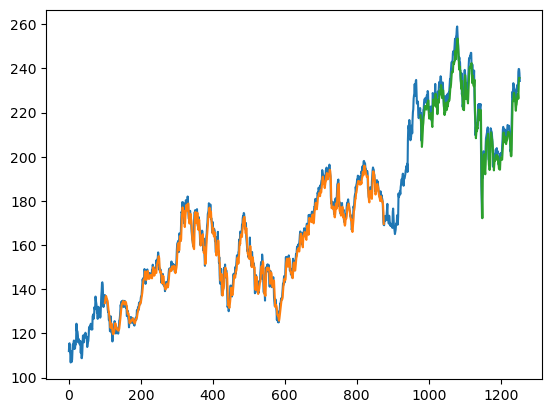

In [162]:
look_back = 100
trainPredictPlot = np.empty_like(df_close)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[look_back:len(train_predict)+look_back, :] = train_predict

testPredictPlot = np.empty_like(df_close)
testPredictPlot[:, :] = np.nan
testPredictPlot[len(train_predict)+(look_back*2)+1:len(df_close)-1, :] = test_predict

plt.plot(scaler.inverse_transform(df_close))
plt.plot(trainPredictPlot)
plt.plot(testPredictPlot)
plt.show()

In [163]:
len(test_data)

377

In [164]:
x_input=test_data[277:].reshape(1,-1)
x_input.shape

(1, 100)

In [165]:
temp_input=list(x_input)
temp_input=temp_input[0].tolist()

In [ ]:
temp_input

In [ ]:
from numpy import array

lst_output=[]
n_steps=100
i=0
while(i<30):
    
    if(len(temp_input)>100):
        #print(temp_input)
        x_input=np.array(temp_input[1:])
        print("{} day input {}".format(i,x_input))
        x_input=x_input.reshape(1,-1)
        x_input = x_input.reshape((1, n_steps, 1))
        #print(x_input)
        yhat = model.predict(x_input, verbose=0)
        print("{} day output {}".format(i,yhat))
        temp_input.extend(yhat[0].tolist())
        temp_input=temp_input[1:]
        #print(temp_input)
        lst_output.extend(yhat.tolist())
        i=i+1
    else:
        x_input = x_input.reshape((1, n_steps,1))
        yhat = model.predict(x_input, verbose=0)
        print(yhat[0])
        temp_input.extend(yhat[0].tolist())
        print(len(temp_input))
        lst_output.extend(yhat.tolist())
        i=i+1

In [168]:
day_new=np.arange(1,101)
day_pred=np.arange(101,131)

In [169]:
len(df_close)

1254

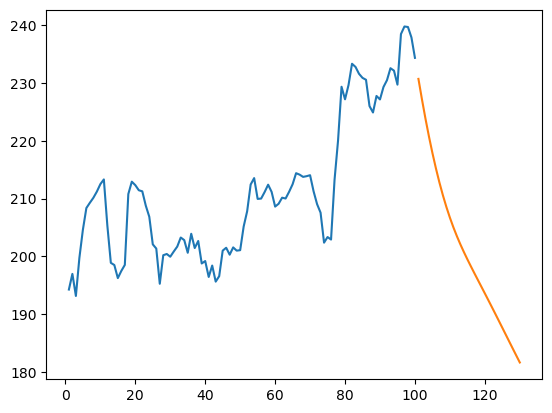

In [170]:
plt.plot(day_new,scaler.inverse_transform(df_close[1154:]))
plt.plot(day_pred,scaler.inverse_transform(lst_output))

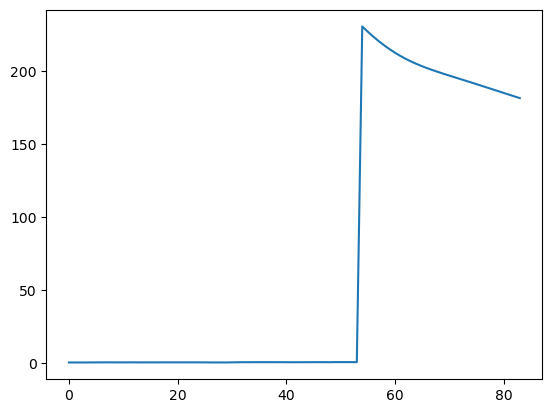

In [183]:
df3=df_close.tolist()
df3.extend(lst_output)
plt.plot(df3[1200:])

In [172]:
df3=scaler.inverse_transform(df3).tolist()

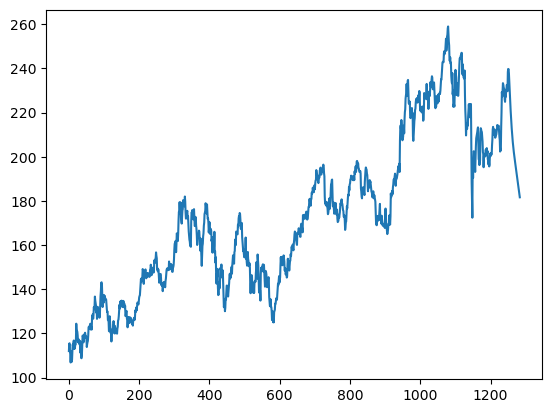

In [173]:
plt.plot(df3)

In [178]:
lst_output= scaler.inverse_transform(lst_output)

In [10]:
import pandas as pd

df = pd.read_csv("AAPL.csv", index_col=0, parse_dates=True)